# LV3 Second Term Project
## GitHub Machine Learning Repositories Analysis

**Student Name:** Moatasem Saudi  
**GitHub Repository:** https://github.com/moatsmsoudi123-spec/LV3-SecondTermProject

In [100]:
# Import the required libraries

import requests
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

In [101]:
# GitHub API URL for Machine Learning repositories

url = "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"

In [102]:
# Send a request to the GitHub API

response = requests.get(url)

# Check the response status
print(response.status_code)

200


In [103]:
# Convert the API response into JSON format

data = response.json()

# Display the main keys in the JSON response
print(data.keys())

dict_keys(['total_count', 'incomplete_results', 'items'])


In [104]:
# Create a Pandas DataFrame from the repositories data

df = pd.DataFrame(data["items"])

# Display the first 5 rows
df.head()

,id,node_id,name,full_name,private,owner,html_url,description,fork,url,...,web_commit_signoff_required,has_pull_requests,pull_request_creation_policy,topics,visibility,forks,open_issues,watchers,default_branch,score
0,45717250,MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==,tensorflow,tensorflow/tensorflow,False,"{'login': 'tensorflow', 'id': 15658638, 'node_...",https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,False,https://api.github.com/repos/tensorflow/tensor...,...,False,True,all,"[deep-learning, deep-neural-networks, distribu...",public,76062,3033,197058,master,1.0
1,155220641,MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=,transformers,huggingface/transformers,False,"{'login': 'huggingface', 'id': 25720743, 'node...",https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,False,https://api.github.com/repos/huggingface/trans...,...,False,True,all,"[audio, deep-learning, deepseek, gemma, glm, h...",public,34277,2381,164251,main,1.0
2,343965132,MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=,ML-For-Beginners,microsoft/ML-For-Beginners,False,"{'login': 'microsoft', 'id': 6154722, 'node_id...",https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",False,https://api.github.com/repos/microsoft/ML-For-...,...,False,True,all,"[data-science, education, machine-learning, ma...",public,21977,13,89514,main,1.0
3,145553672,MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=,funNLP,fighting41love/funNLP,False,"{'login': 'fighting41love', 'id': 11475294, 'n...",https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,False,https://api.github.com/repos/fighting41love/fu...,...,False,True,all,[],public,15266,52,82540,master,1.0
4,21872392,MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==,awesome-machine-learning,josephmisiti/awesome-machine-learning,False,"{'login': 'josephmisiti', 'id': 246302, 'node_...",https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,False,https://api.github.com/repos/josephmisiti/awes...,...,False,True,all,[],public,15612,26,74068,master,1.0


In [105]:
# Display information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 82 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            100 non-null    int64  
 1   node_id                       100 non-null    object 
 2   name                          100 non-null    object 
 3   full_name                     100 non-null    object 
 4   private                       100 non-null    bool   
 5   owner                         100 non-null    object 
 6   html_url                      100 non-null    object 
 7   description                   100 non-null    object 
 8   fork                          100 non-null    bool   
 9   url                           100 non-null    object 
 10  forks_url                     100 non-null    object 
 11  keys_url                      100 non-null    object 
 12  collaborators_url             100 non-null    object 
 13  teams_

In [106]:
# Display all column names

df.columns

Index(['id', 'node_id', 'name', 'full_name', 'private', 'owner', 'html_url',
       'description', 'fork', 'url', 'forks_url', 'keys_url',
       'collaborators_url', 'teams_url', 'hooks_url', 'issue_events_url',
       'events_url', 'assignees_url', 'branches_url', 'tags_url', 'blobs_url',
       'git_tags_url', 'git_refs_url', 'trees_url', 'statuses_url',
       'languages_url', 'stargazers_url', 'contributors_url',
       'subscribers_url', 'subscription_url', 'commits_url', 'git_commits_url',
       'comments_url', 'issue_comment_url', 'contents_url', 'compare_url',
       'merges_url', 'archive_url', 'downloads_url', 'issues_url', 'pulls_url',
       'milestones_url', 'notifications_url', 'labels_url', 'releases_url',
       'deployments_url', 'created_at', 'updated_at', 'pushed_at', 'git_url',
       'ssh_url', 'clone_url', 'svn_url', 'homepage', 'size',
       'stargazers_count', 'watchers_count', 'language', 'has_issues',
       'has_projects', 'has_downloads', 'has_wiki', 'has

In [107]:
# Select only the columns required for the project

required_columns = [
    "name",
    "owner",
    "language",
    "stargazers_count",
    "forks_count",
    "watchers_count",
    "open_issues_count",
    "created_at",
    "updated_at",
    "license"
]

df = df[required_columns]

# Display the first 5 rows
df.head()

,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,"{'login': 'tensorflow', 'id': 15658638, 'node_...",C++,197058,76062,197058,3033,2015-11-07T01:19:20Z,2026-08-19T09:45:53Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
1,transformers,"{'login': 'huggingface', 'id': 25720743, 'node...",Python,164251,34277,164251,2381,2018-10-29T13:56:00Z,2026-08-19T10:23:38Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
2,ML-For-Beginners,"{'login': 'microsoft', 'id': 6154722, 'node_id...",Jupyter Notebook,89514,21977,89514,13,2021-03-03T01:34:05Z,2026-08-19T10:19:53Z,"{'key': 'mit', 'name': 'MIT License', 'spdx_id..."
3,funNLP,"{'login': 'fighting41love', 'id': 11475294, 'n...",Python,82540,15266,82540,52,2018-08-21T11:20:39Z,2026-08-19T10:14:26Z,None
4,awesome-machine-learning,"{'login': 'josephmisiti', 'id': 246302, 'node_...",Python,74068,15612,74068,26,2014-07-15T19:11:19Z,2026-08-19T08:22:02Z,"{'key': 'other', 'name': 'Other', 'spdx_id': '..."


In [108]:
# Check the new shape of the dataset

df.shape

(100, 10)

In [109]:
# Display the selected column names

df.columns

Index(['name', 'owner', 'language', 'stargazers_count', 'forks_count',
       'watchers_count', 'open_issues_count', 'created_at', 'updated_at',
       'license'],
      dtype='object')

In [110]:
# Extract the repository owner's username from the nested owner data

df["owner"] = df["owner"].apply(lambda x: x["login"])

In [111]:
# Extract the license name from the nested license data
# Keep missing licenses as None

df["license"] = df["license"].apply(
    lambda x: x["name"] if x is not None else None
)

In [112]:
# Display the repository name, owner, and license

df[["name", "owner", "license"]].head()

,name,owner,license
0,tensorflow,tensorflow,Apache License 2.0
1,transformers,huggingface,Apache License 2.0
2,ML-For-Beginners,microsoft,MIT License
3,funNLP,fighting41love,None
4,awesome-machine-learning,josephmisiti,Other


In [113]:
# Check the number of missing values in each column

df.isnull().sum()

,0
name,0
owner,0
language,23
stargazers_count,0
forks_count,0
watchers_count,0
open_issues_count,0
created_at,0
updated_at,0
license,22


In [114]:
# Calculate the percentage of missing values in each column

df.isnull().mean() * 100

,0
name,0.0
owner,0.0
language,23.0
stargazers_count,0.0
forks_count,0.0
watchers_count,0.0
open_issues_count,0.0
created_at,0.0
updated_at,0.0
license,22.0


In [115]:
# Replace missing programming languages with "Unknown"

df["language"] = df["language"].fillna("Unknown")

In [116]:
# Replace missing licenses with "Unknown"

df["license"] = df["license"].fillna("Unknown")

In [117]:
# Check missing values again after handling them

df.isnull().sum()

,0
name,0
owner,0
language,0
stargazers_count,0
forks_count,0
watchers_count,0
open_issues_count,0
created_at,0
updated_at,0
license,0


In [118]:
# Check the number of duplicate rows

df.duplicated().sum()

np.int64(0)

In [119]:
# Remove duplicate records

df = df.drop_duplicates()

In [120]:
# Check duplicates again

df.duplicated().sum()

np.int64(0)

In [121]:
df["created_at"] = pd.to_datetime(df["created_at"])
df["updated_at"] = pd.to_datetime(df["updated_at"])

In [122]:
# Rename columns to make them shorter and easier to use in SQL

df = df.rename(columns={
    "stargazers_count": "stars",
    "forks_count": "forks",
    "watchers_count": "watchers",
    "open_issues_count": "open_issues",
    "created_at": "created_date",
    "updated_at": "updated_date"
})

In [123]:
# Display the prepared dataset

df.head()

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197058,76062,197058,3033,2015-11-07 01:19:20+00:00,2026-08-19 09:45:53+00:00,Apache License 2.0
1,transformers,huggingface,Python,164251,34277,164251,2381,2018-10-29 13:56:00+00:00,2026-08-19 10:23:38+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89514,21977,89514,13,2021-03-03 01:34:05+00:00,2026-08-19 10:19:53+00:00,MIT License
3,funNLP,fighting41love,Python,82540,15266,82540,52,2018-08-21 11:20:39+00:00,2026-08-19 10:14:26+00:00,Unknown
4,awesome-machine-learning,josephmisiti,Python,74068,15612,74068,26,2014-07-15 19:11:19+00:00,2026-08-19 08:22:02+00:00,Other


In [124]:
# Check the final dataset structure and data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   name          100 non-null    object             
 1   owner         100 non-null    object             
 2   language      100 non-null    object             
 3   stars         100 non-null    int64              
 4   forks         100 non-null    int64              
 5   watchers      100 non-null    int64              
 6   open_issues   100 non-null    int64              
 7   created_date  100 non-null    datetime64[ns, UTC]
 8   updated_date  100 non-null    datetime64[ns, UTC]
 9   license       100 non-null    object             
dtypes: datetime64[ns, UTC](2), int64(4), object(4)
memory usage: 7.9+ KB


In [125]:
# Check the final number of rows and columns

df.shape

(100, 10)

In [126]:
# Save the prepared dataset as a CSV file

df.to_csv("github_projects.csv", index=False)

In [127]:
# Reload the saved CSV file to verify that it was saved correctly

df_check = pd.read_csv("github_projects.csv")

df_check.head()

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197058,76062,197058,3033,2015-11-07 01:19:20+00:00,2026-08-19 09:45:53+00:00,Apache License 2.0
1,transformers,huggingface,Python,164251,34277,164251,2381,2018-10-29 13:56:00+00:00,2026-08-19 10:23:38+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89514,21977,89514,13,2021-03-03 01:34:05+00:00,2026-08-19 10:19:53+00:00,MIT License
3,funNLP,fighting41love,Python,82540,15266,82540,52,2018-08-21 11:20:39+00:00,2026-08-19 10:14:26+00:00,Unknown
4,awesome-machine-learning,josephmisiti,Python,74068,15612,74068,26,2014-07-15 19:11:19+00:00,2026-08-19 08:22:02+00:00,Other


In [128]:
# Check the saved dataset shape

df_check.shape

(100, 10)

In [129]:
# Check the saved dataset information

df_check.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   name          100 non-null    object
 1   owner         100 non-null    object
 2   language      100 non-null    object
 3   stars         100 non-null    int64 
 4   forks         100 non-null    int64 
 5   watchers      100 non-null    int64 
 6   open_issues   100 non-null    int64 
 7   created_date  100 non-null    object
 8   updated_date  100 non-null    object
 9   license       100 non-null    object
dtypes: int64(4), object(6)
memory usage: 7.9+ KB


In [130]:
# Create a SQLite database

connection = sqlite3.connect("github_projects.db")

In [131]:
# Import the prepared dataset into a SQLite table named Repositories

df_check.to_sql("Repositories", connection, if_exists="replace", index=False)

100

In [132]:
# Display the first 5 records from the Repositories table

query = """
SELECT *
FROM Repositories
LIMIT 5;
"""

pd.read_sql_query(query, connection)

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197058,76062,197058,3033,2015-11-07 01:19:20+00:00,2026-08-19 09:45:53+00:00,Apache License 2.0
1,transformers,huggingface,Python,164251,34277,164251,2381,2018-10-29 13:56:00+00:00,2026-08-19 10:23:38+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89514,21977,89514,13,2021-03-03 01:34:05+00:00,2026-08-19 10:19:53+00:00,MIT License
3,funNLP,fighting41love,Python,82540,15266,82540,52,2018-08-21 11:20:39+00:00,2026-08-19 10:14:26+00:00,Unknown
4,awesome-machine-learning,josephmisiti,Python,74068,15612,74068,26,2014-07-15 19:11:19+00:00,2026-08-19 08:22:02+00:00,Other


In [133]:
# Find repositories with more than 10,000 stars

query = """
SELECT name, owner, stars
FROM Repositories
WHERE stars > 10000
ORDER BY stars DESC;
"""

pd.read_sql_query(query, connection)

,name,owner,stars
0,tensorflow,tensorflow,197058
1,transformers,huggingface,164251
2,ML-For-Beginners,microsoft,89514
3,funNLP,fighting41love,82540
4,awesome-machine-learning,josephmisiti,74068
...,...,...,...
65,machine-learning-systems-design,chiphuyen,10530
66,Machine-Learning,Jack-Cherish,10369
67,machine-learning-notes,roboticcam,10332
68,3D-Machine-Learning,timzhang642,10193


In [134]:
# Find repositories whose names contain the word "Machine"

query = """
SELECT name, owner, stars
FROM Repositories
WHERE name LIKE '%Machine%';
"""

pd.read_sql_query(query, connection)

,name,owner,stars
0,awesome-machine-learning,josephmisiti,74068
1,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,36375
2,machine-learning-for-software-engineers,ZuzooVn,28865
3,homemade-machine-learning,trekhleb,24768
4,awesome-production-machine-learning,EthicalML,20852
5,machine-learning-for-trading,stefan-jansen,20512
6,stanford-cs-229-machine-learning,afshinea,20127
7,Machine-Learning-Tutorials,ujjwalkarn,18109
8,machine-learning-zoomcamp,DataTalksClub,13942
9,machine-learning-interview,khangich,12784


In [135]:
# Use AND to find repositories with more than 10,000 stars
# and more than 1,000 forks

query = """
SELECT name, stars, forks
FROM Repositories
WHERE stars > 10000 AND forks > 1000
ORDER BY stars DESC;
"""

pd.read_sql_query(query, connection)

,name,stars,forks
0,tensorflow,197058,76062
1,transformers,164251,34277
2,ML-For-Beginners,89514,21977
3,funNLP,82540,15266
4,awesome-machine-learning,74068,15612
...,...,...,...
64,machine-learning-systems-design,10530,1631
65,Machine-Learning,10369,5065
66,machine-learning-notes,10332,1825
67,3D-Machine-Learning,10193,1797


In [136]:
# Use OR to find repositories with more than 50,000 stars
# or more than 20,000 forks

query = """
SELECT name, stars, forks
FROM Repositories
WHERE stars > 50000 OR forks > 20000
ORDER BY stars DESC;
"""

pd.read_sql_query(query, connection)

,name,stars,forks
0,tensorflow,197058,76062
1,transformers,164251,34277
2,ML-For-Beginners,89514,21977
3,funNLP,82540,15266
4,awesome-machine-learning,74068,15612
5,scikit-learn,66973,27292


In [137]:
# Use NOT to exclude repositories written in Python

query = """
SELECT name, language, stars
FROM Repositories
WHERE NOT language = 'Python'
ORDER BY stars DESC;
"""

pd.read_sql_query(query, connection)

,name,language,stars
0,tensorflow,C++,197058
1,ML-For-Beginners,Jupyter Notebook,89514
2,500-AI-Machine-learning-Deep-learning-Computer...,Unknown,36375
3,C-Plus-Plus,C++,34588
4,netron,JavaScript,33366
...,...,...,...
65,Machine-learning-learning-notes,Unknown,7762
66,awesome-youtubers,Markdown,7696
67,Learn_Machine_Learning_in_3_Months,Unknown,7606
68,h2o-3,Jupyter Notebook,7492


In [138]:
# Display the Top 10 repositories with the highest number of stars

query = """
SELECT name, owner, language, stars
FROM Repositories
ORDER BY stars DESC
LIMIT 10;
"""

top_10 = pd.read_sql_query(query, connection)

top_10

,name,owner,language,stars
0,tensorflow,tensorflow,C++,197058
1,transformers,huggingface,Python,164251
2,ML-For-Beginners,microsoft,Jupyter Notebook,89514
3,funNLP,fighting41love,Python,82540
4,awesome-machine-learning,josephmisiti,Python,74068
5,scikit-learn,scikit-learn,Python,66973
6,gradio,gradio-app,Python,43383
7,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,36375
8,C-Plus-Plus,TheAlgorithms,C++,34588
9,netron,lutzroeder,JavaScript,33366


In [139]:
# Count the total number of repositories

query = """
SELECT COUNT(*) AS total_repositories
FROM Repositories;
"""

pd.read_sql_query(query, connection)

,total_repositories
0,100


In [140]:
# Calculate the average number of stars

query = """
SELECT AVG(stars) AS average_stars
FROM Repositories;
"""

pd.read_sql_query(query, connection)

,average_stars
0,20807.0


In [141]:
# Group repositories by programming language
# Display only languages with more than 5 repositories

query = """
SELECT language, COUNT(*) AS repository_count
FROM Repositories
GROUP BY language
HAVING COUNT(*) > 5
ORDER BY repository_count DESC;
"""

language_analysis = pd.read_sql_query(query, connection)

language_analysis

,language,repository_count
0,Python,30
1,Unknown,23
2,Jupyter Notebook,19
3,C++,12


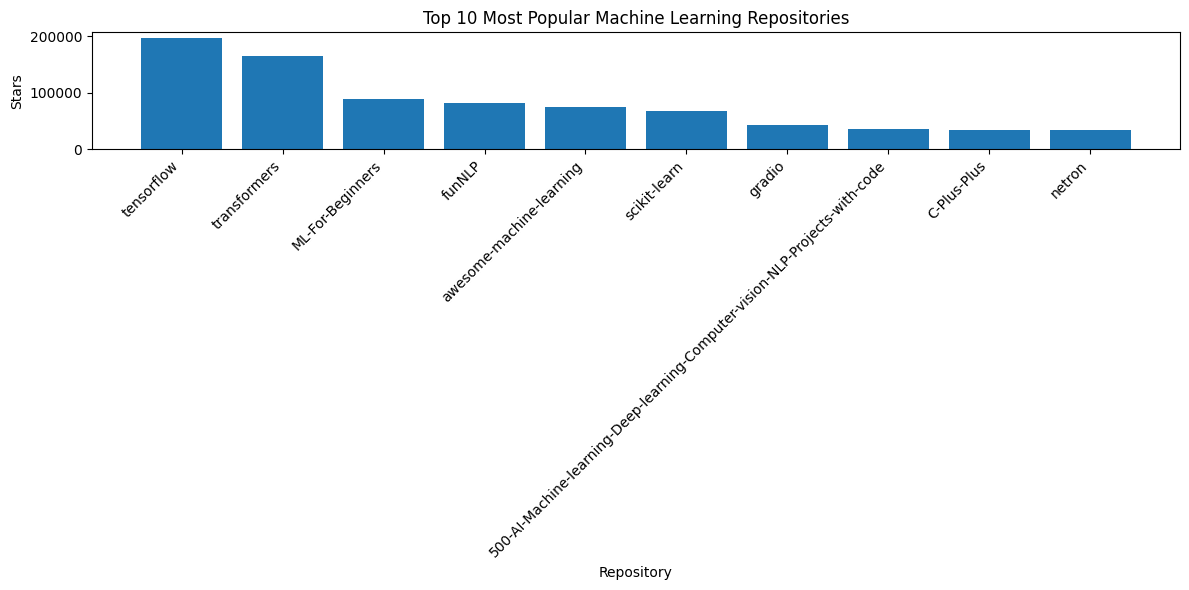

In [142]:
# Create a bar chart for the Top 10 most popular repositories

plt.figure(figsize=(12, 6))

plt.bar(top_10["name"], top_10["stars"])

plt.title("Top 10 Most Popular Machine Learning Repositories")
plt.xlabel("Repository")
plt.ylabel("Stars")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [143]:
# Extract the repository creation year

df_check["created_date"] = pd.to_datetime(df_check["created_date"])

df_check["created_year"] = df_check["created_date"].dt.year

creation_trend = (
    df_check.groupby("created_year")
    .size()
    .reset_index(name="repository_count")
)

creation_trend

,created_year,repository_count
0,2009,1
1,2010,2
2,2011,2
3,2013,3
4,2014,6
5,2015,7
6,2016,14
7,2017,17
8,2018,18
9,2019,7


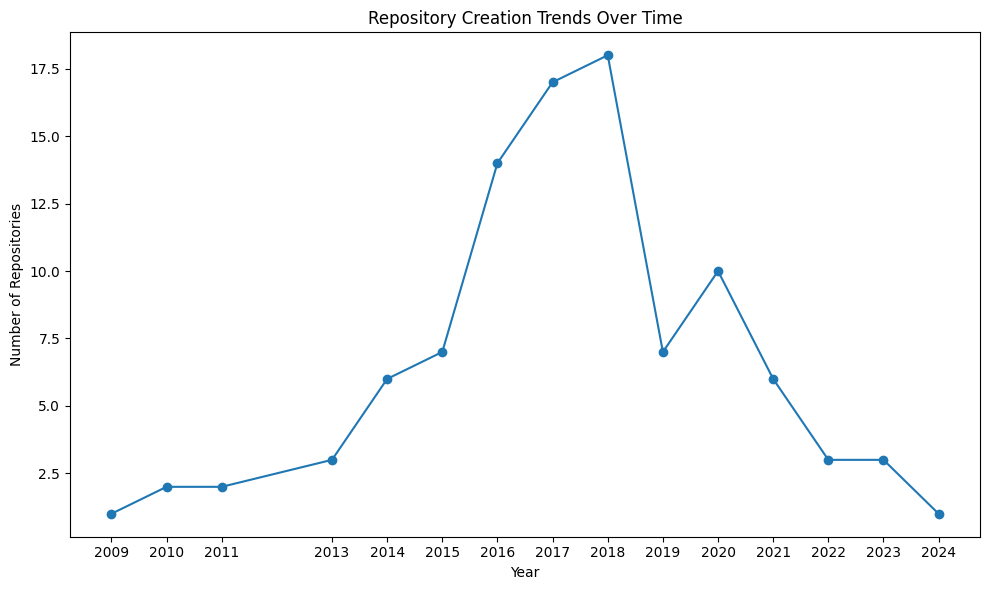

In [144]:
# Create a line chart showing repository creation trends over time

plt.figure(figsize=(10, 6))

plt.plot(
    creation_trend["created_year"],
    creation_trend["repository_count"],
    marker="o"
)

plt.title("Repository Creation Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Repositories")

plt.xticks(creation_trend["created_year"])

plt.tight_layout()
plt.show()

## Insights

- TensorFlow is the most popular repository in the dataset based on the number of stars, followed by Transformers and ML-For-Beginners.

- The Top 10 repositories show that a small group of Machine Learning projects receives significantly higher attention from the GitHub community.

- The dataset contains 100 Machine Learning repositories.

- Python is one of the most common programming languages among the analyzed repositories. Some repositories have missing language information, which was handled as Unknown.

- The repository creation trend shows that the number of Machine Learning repositories increased significantly over the years, with the highest activity appearing around 2017–2018.

- After the peak period, the number of newly created repositories generally decreased, showing that repository creation activity was not constant over time.

- These findings can help developers and software companies understand popular Machine Learning projects, programming language usage, and GitHub activity patterns.

## Ethics Reflection

### Question 1: Why is it important to verify data collected from public APIs?

It is important to verify data collected from public APIs because the data may contain missing, incorrect, or unexpected values. Checking the data helps make sure that the analysis is based on reliable information.

### Question 2: Why should data analysts document the source of their data?

Data analysts should document the source of their data so that others can understand where the data came from, verify the information, and reproduce the analysis.

### Question 3: How can missing or inaccurate data affect data analysis and decision-making?

Missing or inaccurate data can lead to incorrect results and misleading insights. This can affect decisions because the conclusions may not represent the real situation.

## GitHub Repository

GitHub Repository: https://github.com/moatsmsoudi123-spec/LV3-SecondTermProject